# LandscapeModel: toy example



In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import urllib.request
from pathlib import Path

In [2]:


import numpy as np
import matplotlib.pyplot as plt

from model import LandscapeModel
import hyperparameters as hp

## Checkpoint
From here:
https://zenodo.org/records/22961951

In [11]:
CKPT_URL = "https://zenodo.org/records/22961951/files/landscapeweights.pt?download=1"
CKPT_PATH = Path("landscapeweights.pt")

if not CKPT_PATH.exists():
    print(f"Downloading checkpoint")
    urllib.request.urlretrieve(CKPT_URL, CKPT_PATH)
    print("done")
else:
    print(f"Checkpoint already downloaded: {CKPT_PATH}")

Checkpoint already present: landscapeweights.pt


## Load the torsion function model


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else
                      "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

model = LandscapeModel(in_channels=hp.IN_CHANNELS, n_eig=hp.N_EIG, base_ch=hp.BASE_CH)

ckpt = torch.load(CKPT_PATH, map_location="cpu", weights_only=False)
state = ckpt.get("ema_state", ckpt.get("model_state", ckpt))
model.load_state_dict(state)
model.eval().to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"LandscapeModel loaded: {n_params:,} parameters")

Device: mps
LandscapeModel loaded: 7,796,587 parameters


## Network input for ellipse (a,b) 

The landscape function:
$$u(x, y) = \frac{a^2 b^2}{2(a^2+b^2)} \left(1 - \frac{x^2}{a^2} - \frac{y^2}{b^2}\right)$$


In [5]:
G = hp.GRID_SIZE


def ellipse_torsion(a, b, G=G, margin=0.12):
    box = max(a, b) * (1.0 + margin)
    xs = torch.linspace(-box, box, G)
    X, Y = torch.meshgrid(xs, xs, indexing="xy")
    K = (a**2 * b**2) / (2.0 * (a**2 + b**2))
    phi = K * (1.0 - X**2 / a**2 - Y**2 / b**2)
    return phi


def build_input(phi):
    u = phi.clamp(min=0.0)
    umax = u.max().clamp(min=1e-8)

    W_ch = torch.sigmoid(-10.0 * phi / umax)
    u_ch = u / umax
    mask_ch = (u_ch > 1e-3).float()

    du_dx = torch.gradient(u_ch, dim=1)[0]
    du_dy = torch.gradient(u_ch, dim=0)[0]
    grad2 = (du_dx**2 + du_dy**2) * mask_ch
    grad2_ch = grad2 / grad2.max().clamp(min=1e-12)

    x = torch.stack([W_ch, u_ch, grad2_ch]).unsqueeze(0)
    model_mask = (u_ch.unsqueeze(0).unsqueeze(0) > 0.02).float()
    log_umax = torch.log(umax).reshape(1, 1)
    return x, log_umax, model_mask, umax

## Predict $\lambda_1$

In [12]:
a, b = 1.0, 0.5   # ellipse axes

phi = ellipse_torsion(torch.tensor(float(a)), torch.tensor(float(b)))
x, log_umax, mask, umax = build_input(phi)
x, log_umax, mask = x.to(device), log_umax.to(device), mask.to(device)

with torch.no_grad():
    _, log_lam1_umax = model(x, log_umax, mask)
lam1_pred = (torch.exp(log_lam1_umax.squeeze()) / umax.to(device)).item()

print(f"Ellipse :a={a}, b={b}")
print(f"Predicted lambda_1:{lam1_pred}")


Ellipse :a=1.0, b=0.5
Predicted lambda_1:14.369254112243652


## Just to visualize the landscape function

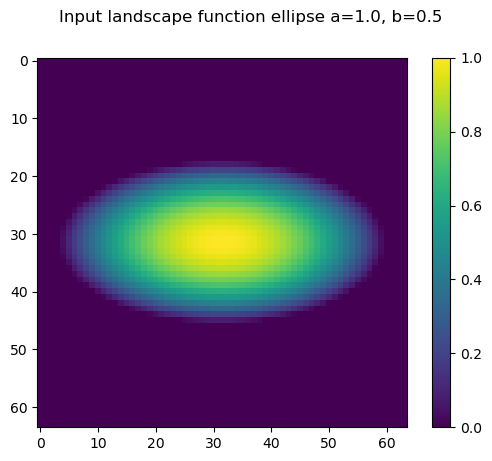

In [15]:
fig, ax = plt.subplots()
titles = ["landscape "]

im = ax.imshow(x[0, 1].cpu(), cmap="viridis")
plt.colorbar(im, ax=ax)
plt.suptitle(f"Input landscape function ellipse a={a}, b={b}")
plt.show()